[*********************100%***********************]  1 of 1 completed

Fetching data for SPY...

--- PERFORMANCE & RISK REPORT ---
Total Return        : 89.37%
Sharpe Ratio        : 1.19
Max Drawdown        : -13.35%
VaR 95% (Daily)     : -1.22%
CVaR 95% (Daily)    : -1.74%


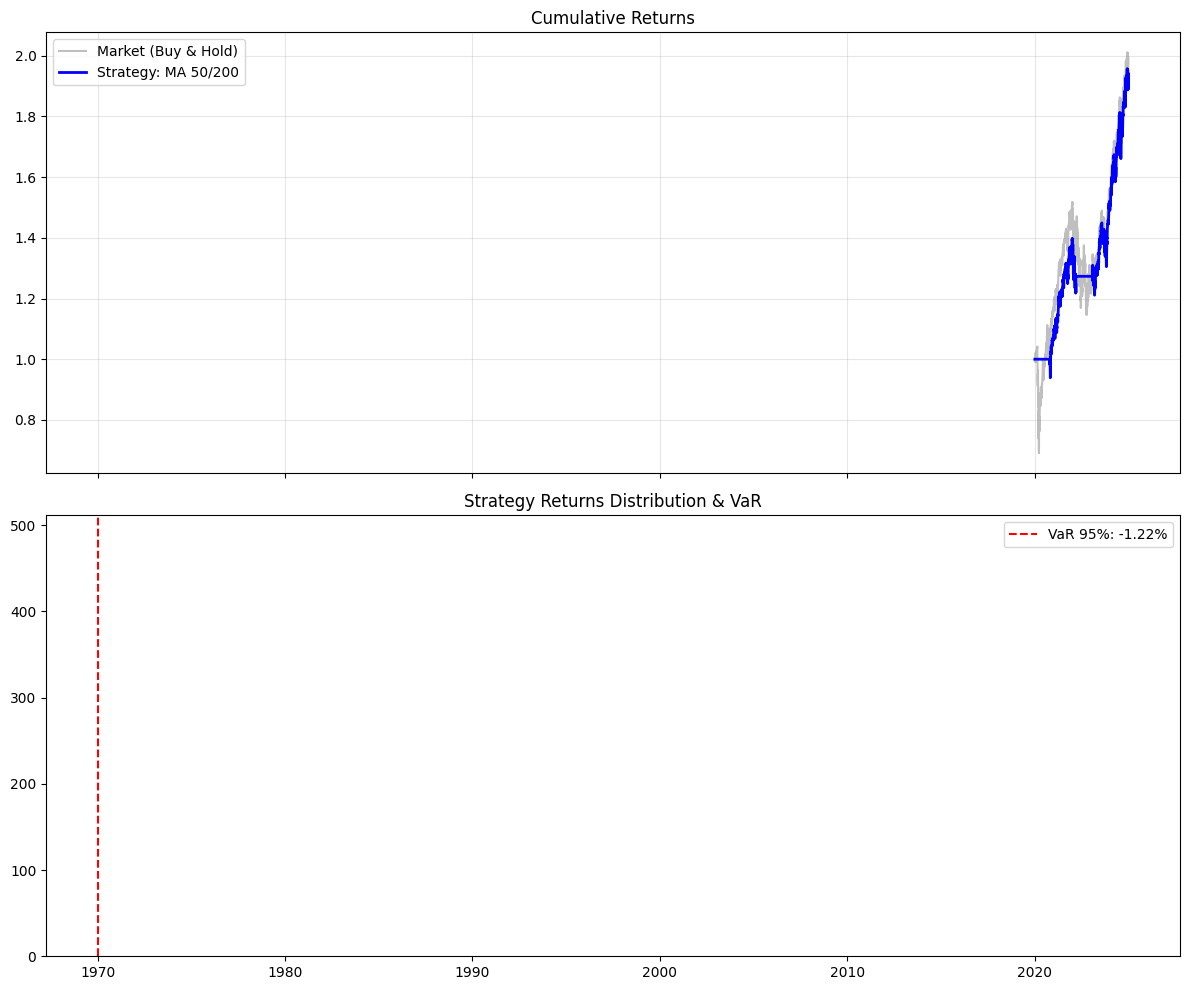

In [7]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sps

class VectorizedBacktester:
    def __init__(self, data, strategy_name="MA_Crossover"):
        self.data = data.copy()
        self.strategy_name = strategy_name
        self.results = None

    def calculate_metrics(self, r_f=0.0):
        """Calcule les indicateurs de performance et de risque."""
        returns = self.data['strategy_returns'].dropna()
        
        # --- Performance ---
        cumulative = (1 + returns).cumprod()
        total_return = (cumulative.iloc[-1] - 1) * 100
        
        # Sharpe Ratio (Annualisé)
        sharpe = np.sqrt(252) * (returns.mean() - r_f) / returns.std()
        
        # --- Risque ---
        # Maximum Drawdown
        peak = cumulative.cummax()
        drawdown = (cumulative - peak) / peak
        max_drawdown = drawdown.min() * 100
        
        # Value at Risk (VaR 95% Historique)
        var_95 = np.percentile(returns, 5)
        
        # Expected Shortfall (CVaR 95%)
        cvar_95 = returns[returns <= var_95].mean()
        
        return {
            "Total Return": f"{total_return:.2f}%",
            "Sharpe Ratio": round(sharpe, 2),
            "Max Drawdown": f"{max_drawdown:.2f}%",
            "VaR 95% (Daily)": f"{var_95*100:.2f}%",
            "CVaR 95% (Daily)": f"{cvar_95*100:.2f}%"
        }

    def plot_results(self):
        """Dashboard de performance."""
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
        
        # Courbe de capital
        cum_market = (1 + self.data['returns']).cumprod()
        cum_strategy = (1 + self.data['strategy_returns']).cumprod()
        
        ax1.plot(cum_market, label="Market (Buy & Hold)", color='gray', alpha=0.5)
        ax1.plot(cum_strategy, label=f"Strategy: {self.strategy_name}", color='blue', lw=2)
        ax1.set_title("Cumulative Returns")
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Distribution des rendements avec VaR
        ax2.hist(self.data['strategy_returns'].dropna(), bins=50, color='blue', alpha=0.4)
        var_95 = np.percentile(self.data['strategy_returns'].dropna(), 5)
        ax2.axvline(var_95, color='red', linestyle='--', label=f'VaR 95%: {var_95*100:.2f}%')
        ax2.set_title("Strategy Returns Distribution & VaR")
        ax2.legend()
        
        plt.tight_layout()
        plt.show()

def run_backtest(ticker="SPY", fast=50, slow=200):
    # 1. Téléchargement robuste
    print(f"Fetching data for {ticker}...")
    raw_data = yf.download(ticker, start="2020-01-01", end="2025-01-01", auto_adjust=True)
    
    # Correction du MultiIndex/KeyError
    df = pd.DataFrame(index=raw_data.index)
    df['close'] = raw_data['Close'] if 'Close' in raw_data.columns else raw_data.iloc[:, 0]
    
    # 2. Logique de stratégie vectorisée
    df['returns'] = df['close'].pct_change()
    df['ma_fast'] = df['close'].rolling(window=fast).mean()
    df['ma_slow'] = df['close'].rolling(window=slow).mean()
    
    # Signal: 1 si Fast > Slow, sinon 0. Shift(1) pour éviter le biais d'anticipation.
    df['position'] = np.where(df['ma_fast'] > df['ma_slow'], 1, 0)
    df['position'] = df['position'].shift(1)
    
    # Coûts de transaction (0.1% par trade)
    commission = 0.001
    df['trades'] = df['position'].diff().fillna(0).abs()
    df['strategy_returns'] = (df['position'] * df['returns']) - (df['trades'] * commission)
    
    # 3. Analyse
    tester = VectorizedBacktester(df, strategy_name=f"MA {fast}/{slow}")
    metrics = tester.calculate_metrics()
    
    print("\n--- PERFORMANCE & RISK REPORT ---")
    for k, v in metrics.items():
        print(f"{k:<20}: {v}")
    
    tester.plot_results()

# Lancement
run_backtest("SPY", fast=50, slow=200)